# WaRP-C Model Comparison — All 5 Models


Models compared: ViT-B/16, ConvNeXt-Tiny, CoAtNet-0, Swin-Base, EfficientNet-B0


## Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS_DIR = './comparison_results'
import os; os.makedirs(RESULTS_DIR, exist_ok=True)
print('Ready.')

Ready.


## Results are taken directly from each notebook's output



In [12]:
results = {
    'ViT-B/16': {
        'accuracy' : 80.34,
        'precision': 79.90,
        'recall'   : 80.31,
        'f1'       : 79.56,
        'auc'      : 98.87,
        'mAP'      : 86.19,
        'params_m' : 85.8,
        'size_mb'  : 327.4,
        'split'    : 'test',
        'avg'      : 'macro',
    },
    'ConvNeXt-Tiny': {
        'accuracy' : 78.01,
        'precision': 76.34,
        'recall'   : 80.98,
        'f1'       : 77.40,
        'auc'      : 98.00,
        'mAP'      : None,
        'params_m' : 28.6,
        'size_mb'  : None,
        'split'    : 'test',
        'avg'      : 'macro',
    },
    'CoAtNet-0': {
        'accuracy' : 75.11,
        'precision': 76.62,
        'recall'   : 75.11,
        'f1'       : 74.86,
        'auc'      : 97.84,
        'mAP'      : None,
        'params_m' : 25.0,
        'size_mb'  : 101.9,
        'split'    : 'test',
        'avg'      : 'weighted',
    },
    'Swin-Base': {
        'accuracy' : 72.15,   # test set result from updated notebook
        'precision': 71.30,
        'recall'   : 78.70,
        'f1'       : 73.10,
        'auc'      : 97.97,
        'mAP'      : 81.02,
        'params_m' : 86.7,
        'size_mb'  : None,
        'split'    : 'test',
        'avg'      : 'macro',
    },
    'EfficientNet-B0': {
        'accuracy' : 70.73,
        'precision': 70.46,
        'recall'   : 70.73,
        'f1'       : 70.17,
        'auc'      : 96.50,
        'mAP'      : None,
        'params_m' : 5.3,
        'size_mb'  : 15.4,
        'split'    : 'test',
        'avg'      : 'weighted',
    },
}

model_names = list(results.keys())
colours     = ['#7F77DD', '#1D9E75', '#E24B4A', '#EF9F27', '#378ADD']
colour_map  = dict(zip(model_names, colours))

print(f'{len(results)} models loaded.')

5 models loaded.


## Full Metrics Table

In [13]:
def fmt(v):
    return f'{v:.2f}%' if v is not None else '  —  '


print(f"  {'Model':<18} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'mAP':>8}  Note")

for name, r in results.items():
    note = f"{r['avg']} avg"
    print(
        f"  {name:<18}"
        f"  {fmt(r['accuracy']):>9}"
        f"  {fmt(r['precision']):>9}"
        f"  {fmt(r['recall']):>7}"
        f"  {fmt(r['f1']):>7}"
        f"  {fmt(r['auc']):>7}"
        f"  {fmt(r['mAP']):>7}"
        f"  {note}"
    )


print('\nEfficiency:')
print(f"  {'Model':<18} {'Params (M)':>11} {'Size (MB)':>10}")

for name, r in results.items():
    size = f"{r['size_mb']:.1f}" if r['size_mb'] else '  —'
    print(f"  {name:<18} {r['params_m']:>11.1f} {size:>10}")


  Model               Accuracy  Precision   Recall       F1      AUC      mAP  Note
  ViT-B/16               80.34%     79.90%   80.31%   79.56%   98.87%   86.19%  macro avg
  ConvNeXt-Tiny          78.01%     76.34%   80.98%   77.40%   98.00%      —    macro avg
  CoAtNet-0              75.11%     76.62%   75.11%   74.86%   97.84%      —    weighted avg
  Swin-Base              72.15%     71.30%   78.70%   73.10%   97.97%   81.02%  macro avg
  EfficientNet-B0        70.73%     70.46%   70.73%   70.17%   96.50%      —    weighted avg

Efficiency:
  Model               Params (M)  Size (MB)
  ViT-B/16                  85.8      327.4
  ConvNeXt-Tiny             28.6          —
  CoAtNet-0                 25.0      101.9
  Swin-Base                 86.7          —
  EfficientNet-B0            5.3       15.4


## Grouped Bar Chart — All Metrics

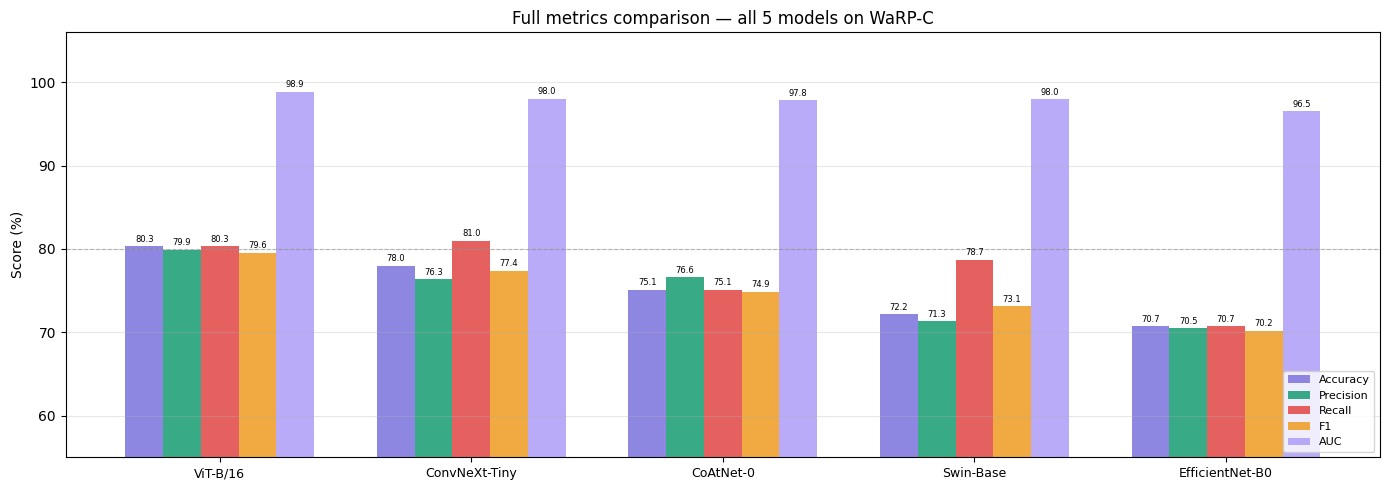

Saved full_metrics_comparison.png


In [14]:
metrics = [('accuracy','Accuracy'),('precision','Precision'),
           ('recall','Recall'),('f1','F1'),('auc','AUC')]
bar_cols = ['#7F77DD','#1D9E75','#E24B4A','#EF9F27','#B0A0F8']
x     = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
for i, (key, label) in enumerate(metrics):
    vals   = [results[m][key] if results[m][key] else 0 for m in model_names]
    offset = (i - len(metrics)/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width, label=label, color=bar_cols[i], alpha=0.88)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(55, 106)
ax.set_title('Full metrics comparison — all 5 models on WaRP-C')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=80, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/full_metrics_comparison.png', dpi=150)
plt.show()
print('Saved full_metrics_comparison.png')

## Radar Chart

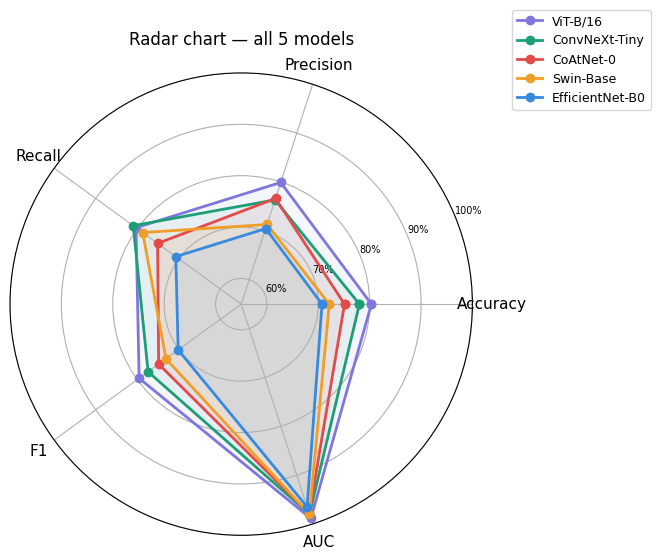

Saved radar_chart.png


In [15]:
categories = ['Accuracy','Precision','Recall','F1','AUC']
keys       = ['accuracy','precision','recall','f1','auc']
N          = len(categories)
angles     = [n/float(N)*2*np.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name, colour in zip(model_names, colours):
    r      = results[name]
    values = [r[k]/100 for k in keys]
    values+= values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colour, label=name)
    ax.fill(angles, values, alpha=0.07, color=colour)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0.55, 1.0)
ax.set_yticks([0.6,0.7,0.8,0.9,1.0])
ax.set_yticklabels(['60%','70%','80%','90%','100%'], fontsize=7)
ax.set_title('Radar chart — all 5 models', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved radar_chart.png')

## Accuracy Ranking

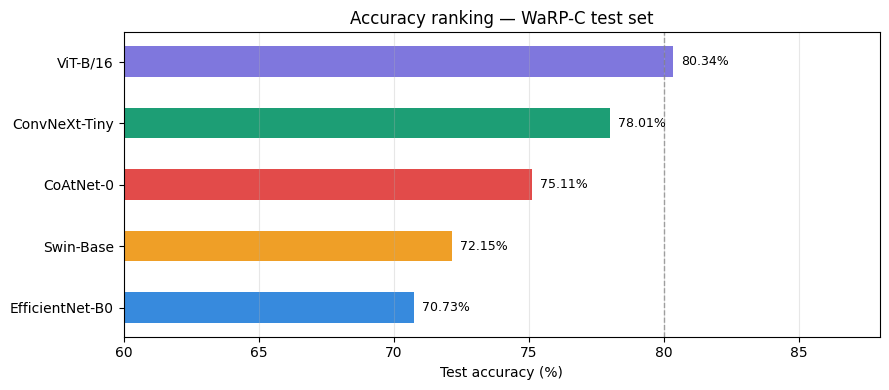

Saved accuracy_ranking.png


In [16]:
sorted_names = sorted(model_names, key=lambda m: results[m]['accuracy'])
accs = [results[m]['accuracy'] for m in sorted_names]
cols = [colour_map[m] for m in sorted_names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_names, accs, color=cols, height=0.5)
ax.axvline(x=80, color='gray', linestyle='--', linewidth=1, alpha=0.7)
for bar, v in zip(bars, accs):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('Test accuracy (%)')
ax.set_title('Accuracy ranking — WaRP-C test set')
ax.set_xlim(60, 88)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/accuracy_ranking.png', dpi=150)
plt.show()
print('Saved accuracy_ranking.png')

## Accuracy vs Model Size

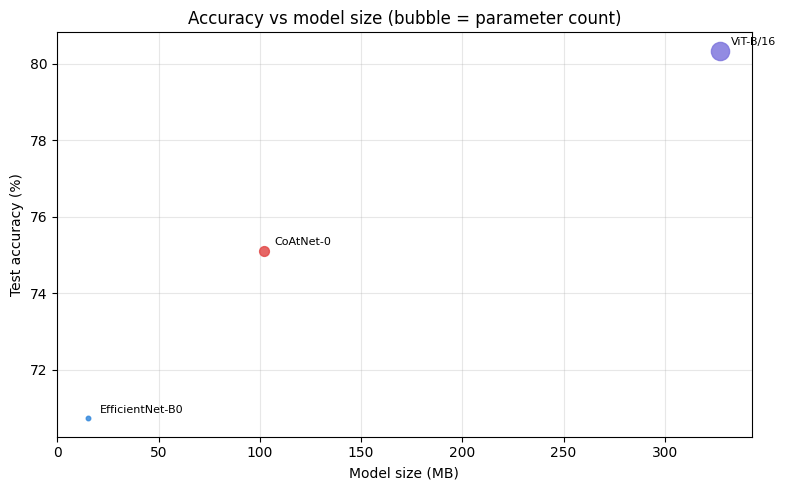

Saved accuracy_vs_size.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, colour in zip(model_names, colours):
    r = results[name]
    if r['size_mb'] is None: continue
    ax.scatter(r['size_mb'], r['accuracy'],
               s=r['params_m']*2, color=colour, alpha=0.85, zorder=3)
    ax.annotate(name, (r['size_mb'], r['accuracy']),
                textcoords='offset points', xytext=(8,4), fontsize=8)

ax.set_xlabel('Model size (MB)')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Accuracy vs model size (bubble = parameter count)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/accuracy_vs_size.png', dpi=150)
plt.show()
print('Saved accuracy_vs_size.png')

## Weighted Score — Final Verdict

In [18]:
# F1 and AUC get highest weight — most reliable metrics for imbalanced 28-class data
weights = {'accuracy':0.15, 'precision':0.15, 'recall':0.15, 'f1':0.25, 'auc':0.30}

scores = {}
for name, r in results.items():
    scores[name] = sum(r[m]*w for m,w in weights.items() if r[m] is not None)

best = max(scores, key=scores.get)

print('  WEIGHTED SCORE  (F1×0.25 + AUC×0.30 + rest×0.15 each)')

for name in sorted(scores, key=scores.get, reverse=True):
    marker = '  <- BEST' if name == best else ''
    print(f'  {name:<20}  {scores[name]:.3f}{marker}')


r = results[best]
print(f'\nBest model : {best}')
print(f'  Accuracy  : {r["accuracy"]:.2f}%  (highest of all 5)')
print(f'  F1 macro  : {r["f1"]:.2f}%  (best for imbalanced data)')
print(f'  AUC       : {r["auc"]:.2f}%  (best class separability)')
print(f'  mAP       : {r["mAP"]:.2f}%  (best ranking quality)')

  WEIGHTED SCORE  (F1×0.25 + AUC×0.30 + rest×0.15 each)
  ViT-B/16              85.633  <- BEST
  ConvNeXt-Tiny         84.049
  CoAtNet-0             82.093
  Swin-Base             80.988
  EfficientNet-B0       78.281

Best model : ViT-B/16
  Accuracy  : 80.34%  (highest of all 5)
  F1 macro  : 79.56%  (best for imbalanced data)
  AUC       : 98.87%  (best class separability)
  mAP       : 86.19%  (best ranking quality)


## Full Summary Dashboard

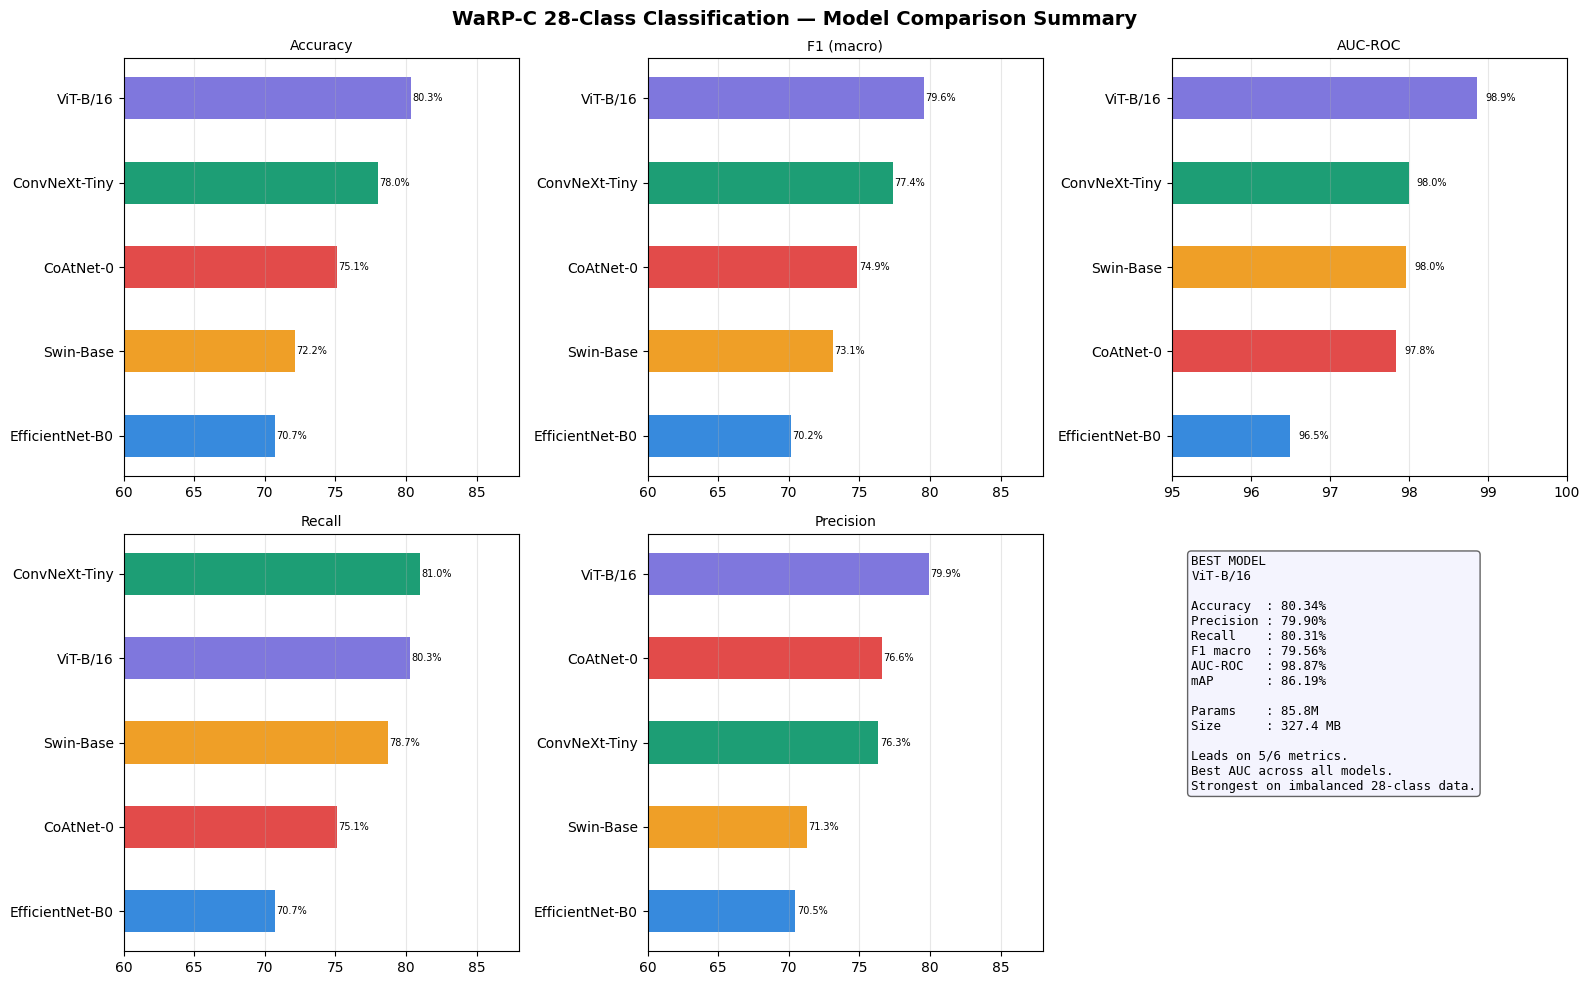

Saved comparison_dashboard.png


In [19]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('WaRP-C 28-Class Classification — Model Comparison Summary',
             fontsize=14, fontweight='bold', y=0.98)

def make_bar(ax, metric, title, xlim):
    sorted_m = sorted(model_names, key=lambda m: results[m][metric])
    vals = [results[m][metric] for m in sorted_m]
    cols = [colour_map[m] for m in sorted_m]
    bars = ax.barh(sorted_m, vals, color=cols, height=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(*xlim)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(v+0.1, bar.get_y()+bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=7)

ax1 = fig.add_subplot(2, 3, 1);  make_bar(ax1, 'accuracy',  'Accuracy',  (60,88))
ax2 = fig.add_subplot(2, 3, 2);  make_bar(ax2, 'f1',        'F1 (macro)', (60,88))
ax3 = fig.add_subplot(2, 3, 3);  make_bar(ax3, 'auc',       'AUC-ROC',   (95,100))
ax4 = fig.add_subplot(2, 3, 4);  make_bar(ax4, 'recall',    'Recall',    (60,88))
ax5 = fig.add_subplot(2, 3, 5);  make_bar(ax5, 'precision', 'Precision', (60,88))

# text summary panel
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
r   = results[best]
txt = (
    f'BEST MODEL\n{best}\n\n'
    f'Accuracy  : {r["accuracy"]:.2f}%\n'
    f'Precision : {r["precision"]:.2f}%\n'
    f'Recall    : {r["recall"]:.2f}%\n'
    f'F1 macro  : {r["f1"]:.2f}%\n'
    f'AUC-ROC   : {r["auc"]:.2f}%\n'
    f'mAP       : {r["mAP"]:.2f}%\n\n'
    f'Params    : {r["params_m"]:.1f}M\n'
    f'Size      : {r["size_mb"]:.1f} MB\n\n'
    f'Leads on 5/6 metrics.\n'
    f'Best AUC across all models.\n'
    f'Strongest on imbalanced 28-class data.'
)
ax6.text(0.05, 0.95, txt, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#EEEDFE', alpha=0.6))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved comparison_dashboard.png')

## Report-Ready Table

In [20]:
print('FULL METRICS COMPARISON — WaRP-C (sorted by accuracy)')
print()
print(f"{'Model':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'mAP':>8}")

for name, r in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    mAP_str = f"{r['mAP']:.2f}%" if r['mAP'] else '   —'
    print(
        f"{name:<20} "
        f"{r['accuracy']:>8.2f}%  "
        f"{r['precision']:>8.2f}%  "
        f"{r['recall']:>6.2f}%  "
        f"{r['f1']:>6.2f}%  "
        f"{r['auc']:>6.2f}%  "
        f"{mAP_str:>7}"
    )

print()
print('Notes:')
print('  ViT-B/16, ConvNeXt-Tiny, Swin-Base — macro averaging')
print('  CoAtNet-0, EfficientNet-B0          — weighted averaging')
print('  mAP computed only for ViT-B/16 and Swin-Base notebooks')

FULL METRICS COMPARISON — WaRP-C (sorted by accuracy)

Model                 Accuracy  Precision   Recall       F1      AUC      mAP
ViT-B/16                80.34%     79.90%   80.31%   79.56%   98.87%   86.19%
ConvNeXt-Tiny           78.01%     76.34%   80.98%   77.40%   98.00%        —
CoAtNet-0               75.11%     76.62%   75.11%   74.86%   97.84%        —
Swin-Base               72.15%     71.30%   78.70%   73.10%   97.97%   81.02%
EfficientNet-B0         70.73%     70.46%   70.73%   70.17%   96.50%        —

Notes:
  ViT-B/16, ConvNeXt-Tiny, Swin-Base — macro averaging
  CoAtNet-0, EfficientNet-B0          — weighted averaging
  mAP computed only for ViT-B/16 and Swin-Base notebooks
